# SYDE 572 Assignment 1: Part 2

## Analytical Approach

GOAL: to fit the following data points to a line and a parabola, with the following equations:

$$
(0,0.5),\quad(1,1.5),\quad(2,3.5),\quad(3,7.5)
$$
$$
\hat y=mx+b
$$
$$
\hat y=ax^2+bx+c
$$

The optimal solution will have a minimized mean square error determined as follows:

$$
\operatorname{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}(\hat y_i-y_i)^2
$$

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# define given points
points = [
    (0, 0.5),
    (2, 3.5),
    (1, 1.5),
    (3, 7.5)
]

x_data = np.array([point[0] for point in points], dtype=float)
y_data = np.array([point[1] for point in points], dtype=float)

#### a) Line
For the line $\hat y=mx+b$, the MSE is: 
$$
\operatorname{MSE}(m,b)
=
\frac14
\sum_{i=1}^{4}
(mx_i+b-y_i)^2
$$

The following sums are calculated & subbed into the expanded MSE as shown below

$$
\sum x_i=6,
\qquad
\sum y_i=13,
$$

$$
\sum x_i^2=14,
\qquad
\sum x_iy_i=31,
$$

$$
\operatorname{MSE}(m,b)
=
3.5m^2+3mb-15.5m+b^2-6.5b+17.75
$$

Taking the partial derivatives & setting them equal to zero:
$$
\frac{\partial MSE}{\partial m}
=
7m+3b-15.5=0
$$

$$
7m+3b=15.5
$$

and
$$
\frac{\partial MSE}{\partial b}
=
3m+2b-6.5=0
$$
$$
3m+2b=6.5
$$
This system of 2 equations is solved below, to get the best fitted line. 

In [2]:
# set number of data points (4)
n = len(x_data)

#cacluate the sums used in the expanded MSE
sum_x = np.sum(x_data)
sum_y = np.sum(y_data)
sum_x_squared = np.sum(x_data**2)
sum_xy = np.sum(x_data * y_data)


# A'A matrix
line_matrix = np.array([
    [sum_x_squared, sum_x],
    [sum_x, n]
], dtype=float)

# A'y vector
line_right_side = np.array([
    sum_xy,
    sum_y
], dtype=float)


# Solve for parameters (m and b) by solving system of equations in matrix form
m_analytical, b_analytical = np.linalg.solve(
    line_matrix,
    line_right_side
)

# ŷ for each 
line_predictions_analytical = (
    m_analytical * x_data
    + b_analytical
)

# calculate mse 
line_mse_analytical = np.mean(
    (line_predictions_analytical - y_data)**2
)

print("Analytical line")
print(f"m = {m_analytical:.4f}")
print(f"b = {b_analytical:.4f}")
print(f"MSE = {line_mse_analytical:.4f}")

# display MSE calculation results for each x with y, ŷ error and squared error  
line_analytical_table = pd.DataFrame({
    "x": x_data,
    "actual_y": y_data,
    "predicted_y": line_predictions_analytical,
    "error": line_predictions_analytical - y_data,
    "squared_error": (
        line_predictions_analytical - y_data
    )**2
})

line_analytical_table

Analytical line
m = 2.3000
b = -0.2000
MSE = 0.5750


,x,actual_y,predicted_y,error,squared_error
0,0.0,0.5,-0.2,-0.7,0.49
1,2.0,3.5,4.4,0.9,0.81
2,1.0,1.5,2.1,0.6,0.36
3,3.0,7.5,6.7,-0.8,0.64


Thus the equation of the line best fit to these points through the Analytical method is 
$$
\hat y=2.3x-0.2
$$
and the MSE for this line is $0.575$

#### b) Parabola 

For the parabola $\hat y=ax^2+bx+c$, the MSE is:

$$
\operatorname{MSE}(a,b,c)
=
\frac14
\sum_{i=1}^{4}
(ax_i^2+bx_i+c-y_i)^2.
$$

The following sums, and the ones that were previously calculated for the best-fitted line, are calculated, subbed into the MSE and simplified:

$$
\sum x_i^3=36,
\qquad
\sum x_i^4=98,
$$

$$
\sum x_i^2y_i=83.
$$

$$
\begin{aligned}
\operatorname{MSE}(a,b,c)
={}&24.5a^2+3.5b^2+c^2+18ab+7ac+3bc-41.5a-15.5b-6.5c+17.75.
\end{aligned}
$$

$$
\frac{\partial \operatorname{MSE}}{\partial a}
=
49a+18b+7c-41.5=0
$$

$$
\frac{\partial \operatorname{MSE}}{\partial b}
=
18a+7b+3c-15.5=0
$$

$$
\frac{\partial \operatorname{MSE}}{\partial c}
=
7a+3b+2c-6.5=0
$$

This system of 3 equations is set up and solved below, to get the best fitted parabola.

In [3]:
# calculate additional sums that are used in the expanded MSE
sum_x_cubed = np.sum(x_data**3)
sum_x_fourth = np.sum(x_data**4)
sum_x_squared_y = np.sum(
    x_data**2 * y_data
)


#  A'A matrix
parabola_matrix = np.array([
    [
        sum_x_fourth,
        sum_x_cubed,
        sum_x_squared
    ],
    [
        sum_x_cubed,
        sum_x_squared,
        sum_x
    ],
    [
        sum_x_squared,
        sum_x,
        n
    ]
], dtype=float)

# A'y vector
parabola_right_side = np.array([
    sum_x_squared_y,
    sum_xy,
    sum_y
], dtype=float)

# solve for parameters (a,b,c) by by solving system of equations in matrix form
a_analytical, b_parabola_analytical, c_analytical = (
    np.linalg.solve(
        parabola_matrix,
        parabola_right_side
    )
)

# ŷ for each x value
parabola_predictions_analytical = (
    a_analytical * x_data**2
    + b_parabola_analytical * x_data
    + c_analytical
)

# calculate mse 
parabola_mse_analytical = np.mean(
    (
        parabola_predictions_analytical
        - y_data
    )**2
)


print("Analytical parabola")
print(f"a = {a_analytical:.4f}")
print(f"b = {b_parabola_analytical:.4f}")
print(f"c = {c_analytical:.4f}")
print(f"MSE = {parabola_mse_analytical:.4f}")

# display MSE calc results for each x with y, ŷ, error and squared error
parabola_analytical_table = pd.DataFrame({
    "x": x_data,
    "actual_y": y_data,
    "predicted_y": parabola_predictions_analytical,
    "error": (
        parabola_predictions_analytical
        - y_data
    ),
    "squared_error": (
        parabola_predictions_analytical
        - y_data
    )**2
})

parabola_analytical_table

Analytical parabola
a = 0.7500
b = 0.0500
c = 0.5500
MSE = 0.0125


,x,actual_y,predicted_y,error,squared_error
0,0.0,0.5,0.55,0.05,0.0025
1,2.0,3.5,3.65,0.15,0.0225
2,1.0,1.5,1.35,-0.15,0.0225
3,3.0,7.5,7.45,-0.05,0.0025


Thus the equation of the parabola best fit to these points through the Analytical method is 
$$
\hat y=0.75x^2+0.05x+0.55
$$
and the MSE for this parabola is $0.0125$

## Numerical Approach (Newton Raphson)

#### a) Line

For the line $\hat{y}_i=mx_i+b$, the MSE is
$$
\operatorname{MSE}(m,b)
=
\frac{1}{n}
\sum_{i=1}^{n}
(mx_i+b-y_i)^2
$$

In this approach, the parameters will be updated one at a time during each iteration:

1. Hold $b$ constant and optimize $m$
2. Use the new value of $m$ to optimize for $b$
3. Repeat until the changes in $m$ and $b$ are within the tolerance threshold

The partial derivative with respect to $m$ is
$$
\frac{\partial \operatorname{MSE}}{\partial m}
=
\frac{2}{n}
\sum_{i=1}^{n}
x_i(mx_i+b-y_i).
$$

The second partial derivative with respect to $m$ is
$$
\frac{\partial^2 \operatorname{MSE}}{\partial m^2}
=
\frac{2}{n}
\sum_{i=1}^{n}x_i^2
$$

Therefore, the Newton-Raphson update for $m$ is

$$
m^{(k+1)}
=
m^{(k)}
-
\frac{
\frac{\partial \operatorname{MSE}}{\partial m}
}{
\frac{\partial^2 \operatorname{MSE}}{\partial m^2}
}
$$

Using this, the partial derivative with respect to $b$ is calculated using $m^{(k+1)}$

$$
\frac{\partial \operatorname{MSE}}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}
\left(
m^{(k+1)}x_i+b^{(k)}-y_i
\right)
$$

The second partial derivative with respect to $b$ is
$$
\frac{\partial^2 \operatorname{MSE}}{\partial b^2}
=
2
$$

Therefore, the Newton-Raphson update for $b$ is
$$
b^{(k+1)}
=
b^{(k)}
-
\frac{
\frac{\partial \operatorname{MSE}}{\partial b}
}{
\frac{\partial^2 \operatorname{MSE}}{\partial b^2}
}
$$

This continues until
$$
\max
\left(
\left|m^{(k+1)}-m^{(k)}\right|,
\left|b^{(k+1)}-b^{(k)}\right|
\right)
<
\text{tolerance}
$$

In [4]:
#function to calculate mse of line 
def calculate_line_mse(x_data, y_data, m, b):
    # calculate predicted y-values
    predictions = m * x_data + b
    # calculate mean squared error
    mse = np.mean((predictions - y_data)**2)
    return mse

Applying this technique, initial guesses for $m$ and $b$ to determine the best fitted line. The tolerance is set to $10^{-7}$. This is defined in a function below.

In [5]:
def fit_line_newton(
    x_data,
    y_data,
    initial_m=0.0,
    initial_b=0.0,
    tolerance=1e-7,
    max_iterations=100
):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    # set number of data points
    n = len(x_data)

    # set the initial guesses
    m = initial_m
    b = initial_b

    # store the result from every iteration
    history = []

    for i in range(1, max_iterations + 1):

        # calculate derivatives to determine the new m
        predictions = m * x_data + b

        d_mse_dm = (2 / n) * np.sum(
            x_data * (predictions - y_data)
        )

        d2_mse_dm2 = (2 / n) * np.sum(
            x_data**2
        )

        m_new = m - d_mse_dm / d2_mse_dm2

        # use new m to get new b
        predictions_after_m = m_new * x_data + b

        d_mse_db = (2 / n) * np.sum(
            predictions_after_m - y_data
        )

        d2_mse_db2 = 2.0

        b_new = b - d_mse_db / d2_mse_db2

        # calculate the MSE after both updates
        mse_new = calculate_line_mse(
            x_data,
            y_data,
            m_new,
            b_new
        )

        # calculate change to see if within tolerance
        change = max(
            abs(m_new - m),
            abs(b_new - b)
        )

        # add result to history to store 
        history.append({
            "Iteration": i,
            "m": m_new,
            "b": b_new,
            "MSE": mse_new,
            "Change": change
        })

        # update params
        m = m_new
        b = b_new

        # check the stopping condition
        if change < tolerance:
            break

    return {
        "m": m,
        "b": b,
        "MSE": calculate_line_mse(
            x_data,
            y_data,
            m,
            b
        ),
        "Iterations": i,
        "data": pd.DataFrame(history)
    }

This is now applied to the given points, with the initial guesses chosen as 
$$
m^{(0)}=0
\qquad
b^{(0)}=0
$$
The results are displayed in the table for each iteration and the final values for the fitted line are outputted. 

In [6]:
line_newton_result = fit_line_newton(
    x_data,
    y_data,
    initial_m=0.0,
    initial_b=0.0,
    tolerance=1e-7,
    max_iterations=100
)
line_newton_result["data"]

,Iteration,m,b,MSE,Change
0,1,2.214286,-0.071429,0.584184,2.214286e+00
1,2,2.244898,-0.117347,0.578795,4.591837e-02
2,3,2.264577,-0.146866,0.576568,2.951895e-02
3,4,2.277228,-0.165842,0.575648,1.897647e-02
4,5,2.285361,-0.178042,0.575268,1.219916e-02
5,6,2.290589,-0.185884,0.575111,7.842316e-03
6,7,2.293950,-0.190925,0.575046,5.041489e-03
7,8,2.296111,-0.194166,0.575019,3.240957e-03
8,9,2.297500,-0.196250,0.575008,2.083472e-03
9,10,2.298393,-0.197589,0.575003,1.339375e-03


In [7]:
print("Numerical line fitting using Newton-Raphson")
print(f"m = {line_newton_result['m']:.6f}")
print(f"b = {line_newton_result['b']:.6f}")
print(f"MSE = {line_newton_result['MSE']:.6f}")
print(f"Iterations = {line_newton_result['Iterations']}")

Numerical line fitting using Newton-Raphson
m = 2.300000
b = -0.200000
MSE = 0.575000
Iterations = 32


Thus, from the numerical solution
$$
m=2.3
\qquad
b=-0.2
$$

and the best-fitted line using the Newton-Raphson method is
$$
\hat{y}=2.3x-0.2
$$

with the resulting mean squared error of

$$
\operatorname{MSE}=0.575
$$

matching what was determined by the analytical solution.

#### b) Parabola

For the parabola $\hat{y}_i=ax_i^2+bx_i+c$, the MSE is

$$
\operatorname{MSE}(a,b,c)
=
\frac{1}{n}
\sum_{i=1}^{n}
(ax_i^2+bx_i+c-y_i)^2
$$

The parameters will be updated one at a time during each iteration:

1. Hold $b$ and $c$ constant and optimize $a$
2. Use the new value of $a$ to optimize $b$
3. Use the new values of $a$ and $b$ to optimize $c$
4. Repeat until the changes in $a$, $b$, and $c$ are within the tolerance threshold

The partial derivative with respect to $a$ is

$$
\frac{\partial \operatorname{MSE}}{\partial a}
=
\frac{2}{n}
\sum_{i=1}^{n}
x_i^2(ax_i^2+bx_i+c-y_i)
$$

The second partial derivative with respect to $a$ is

$$
\frac{\partial^2 \operatorname{MSE}}{\partial a^2}
=
\frac{2}{n}
\sum_{i=1}^{n}x_i^4
$$

Therefore, the Newton-Raphson update for $a$ is

$$
a^{(k+1)}
=
a^{(k)}
-
\frac{
\frac{\partial \operatorname{MSE}}{\partial a}
}{
\frac{\partial^2 \operatorname{MSE}}{\partial a^2}
}
$$

The new value $a^{(k+1)}$ is then used to update $b$:

$$
\frac{\partial \operatorname{MSE}}{\partial b}
=
\frac{2}{n}
\sum_{i=1}^{n}
x_i
\left(
a^{(k+1)}x_i^2+b^{(k)}x_i+c^{(k)}-y_i
\right)
$$

The second partial derivative with respect to $b$ is

$$
\frac{\partial^2 \operatorname{MSE}}{\partial b^2}
=
\frac{2}{n}
\sum_{i=1}^{n}x_i^2
$$

Therefore, the Newton-Raphson update for $b$ is

$$
b^{(k+1)}
=
b^{(k)}
-
\frac{
\frac{\partial \operatorname{MSE}}{\partial b}
}{
\frac{\partial^2 \operatorname{MSE}}{\partial b^2}
}
$$

Finally, the new values $a^{(k+1)}$ and $b^{(k+1)}$ are used to update $c$:

$$
\frac{\partial \operatorname{MSE}}{\partial c}
=
\frac{2}{n}
\sum_{i=1}^{n}
\left(
a^{(k+1)}x_i^2+b^{(k+1)}x_i+c^{(k)}-y_i
\right)
$$

The second partial derivative with respect to $c$ is

$$
\frac{\partial^2 \operatorname{MSE}}{\partial c^2}
=
2
$$

Therefore, the Newton-Raphson update for $c$ is

$$
c^{(k+1)}
=
c^{(k)}
-
\frac{
\frac{\partial \operatorname{MSE}}{\partial c}
}{
\frac{\partial^2 \operatorname{MSE}}{\partial c^2}
}
$$

This continues until

$$
\max
\left(
\left|a^{(k+1)}-a^{(k)}\right|,
\left|b^{(k+1)}-b^{(k)}\right|,
\left|c^{(k+1)}-c^{(k)}\right|
\right)
<
\text{tolerance}
$$

In [8]:
# function to calculate mse of parabola
def calculate_parabola_mse(x_data, y_data, a, b, c):
    # calculate predicted y-values
    predictions = (
        a * x_data**2
        + b * x_data
        + c
    )
    # calculate mean squared error
    mse = np.mean(
        (predictions - y_data)**2
    )
    return mse

Applying this technique, initial guesses for $a$, $b$, and $c$ are used to determine the best-fitted parabola. The tolerance is set to $1e^{-7}$. This is defined in a function below.

In [9]:
def fit_parabola_newton(
    x_data,
    y_data,
    initial_a=0.0,
    initial_b=0.0,
    initial_c=0.0,
    tolerance=1e-7,
    max_iterations=1000
):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    # set number of data points
    n = len(x_data)

    # set the initial guesses
    a = initial_a
    b = initial_b
    c = initial_c

    # store the result from every iteration
    history = []

    for i in range(1, max_iterations + 1):

        # calculate derivatives to determine the new a
        predictions = (
            a * x_data**2
            + b * x_data
            + c
        )

        d_mse_da = (2 / n) * np.sum(
            x_data**2
            * (predictions - y_data)
        )

        d2_mse_da2 = (2 / n) * np.sum(
            x_data**4
        )

        a_new = a - d_mse_da / d2_mse_da2

        # use new a to get new b
        predictions_after_a = (
            a_new * x_data**2
            + b * x_data
            + c
        )

        d_mse_db = (2 / n) * np.sum(
            x_data
            * (predictions_after_a - y_data)
        )

        d2_mse_db2 = (2 / n) * np.sum(
            x_data**2
        )

        b_new = b - d_mse_db / d2_mse_db2

        # use new a and b to get new c
        predictions_after_a_b = (
            a_new * x_data**2
            + b_new * x_data
            + c
        )

        d_mse_dc = (2 / n) * np.sum(
            predictions_after_a_b - y_data
        )

        d2_mse_dc2 = 2.0

        c_new = c - d_mse_dc / d2_mse_dc2

        # calculate MSE after all three updates
        mse_new = calculate_parabola_mse(
            x_data,
            y_data,
            a_new,
            b_new,
            c_new
        )

        # calculate change to see if within tolerance
        change = max(
            abs(a_new - a),
            abs(b_new - b),
            abs(c_new - c)
        )

        # add result to history to store
        history.append({
            "Iteration": i,
            "a": a_new,
            "b": b_new,
            "c": c_new,
            "MSE": mse_new,
            "Change": change
        })

        # update parameters
        a = a_new
        b = b_new
        c = c_new

        # check the stopping condition
        if change < tolerance:
            break

    return {
        "a": a,
        "b": b,
        "c": c,
        "MSE": calculate_parabola_mse(
            x_data,
            y_data,
            a,
            b,
            c
        ),
        "Iterations": i,
        "data": pd.DataFrame(history)
    }

This is now applied to the given points, with the initial guesses chosen as

$$
a^{(0)}=0
\qquad
b^{(0)}=0
\qquad
c^{(0)}=0
$$

Some of the results are displayed in the table (since there are too many iterations the full table could not be displayed) and the final values for the fitted parabola are outputted.

In [10]:
parabola_newton_result = fit_parabola_newton(
    x_data,
    y_data,
    initial_a=0.0,
    initial_b=0.0,
    initial_c=0.0,
    tolerance=1e-7,
    max_iterations=1000
)

parabola_newton_result["data"]

,Iteration,a,b,c,MSE,Change
0,1,0.846939,0.036443,0.231050,0.117988,8.469388e-01
1,2,0.800544,0.056722,0.363012,0.046400,1.319624e-01
2,3,0.774243,0.067798,0.438452,0.023332,7.543977e-02
3,4,0.759398,0.073641,0.481647,0.015947,4.319492e-02
4,5,0.751080,0.076517,0.506444,0.013608,2.479769e-02
...,...,...,...,...,...,...
271,272,0.749999,0.050003,0.549999,0.012500,1.110528e-07
272,273,0.749999,0.050003,0.549999,0.012500,1.072847e-07
273,274,0.749999,0.050003,0.549999,0.012500,1.036446e-07
274,275,0.749999,0.050003,0.549999,0.012500,1.001279e-07


In [11]:
print("Numerical parabola fitting using Newton-Raphson")
print(f"a = {parabola_newton_result['a']:.6f}")
print(f"b = {parabola_newton_result['b']:.6f}")
print(f"c = {parabola_newton_result['c']:.6f}")
print(f"MSE = {parabola_newton_result['MSE']:.6f}")
print(
    "Iterations =",
    parabola_newton_result["Iterations"]
)

Numerical parabola fitting using Newton-Raphson
a = 0.749999
b = 0.050003
c = 0.549999
MSE = 0.012500
Iterations = 276


Thus, from the numerical solution,

$$
a\approx0.75
\qquad
b\approx0.05
\qquad
c\approx0.55
$$

and the best-fitted parabola using the Newton-Raphson method is

$$
\hat{y}=0.75x^2+0.05x+0.55
$$

with the resulting mean squared error of

$$
\operatorname{MSE}=0.0125
$$

matching what was determined by the analytical solution.

### Plots
#### a) Line
The following plot shows the resulting line from each of the iterations of the Newton-Raphson method. The initial guess is the gray dotted line, each iteration is shown in light green and the final fitted line is shown in red. The given data points are also displayed.

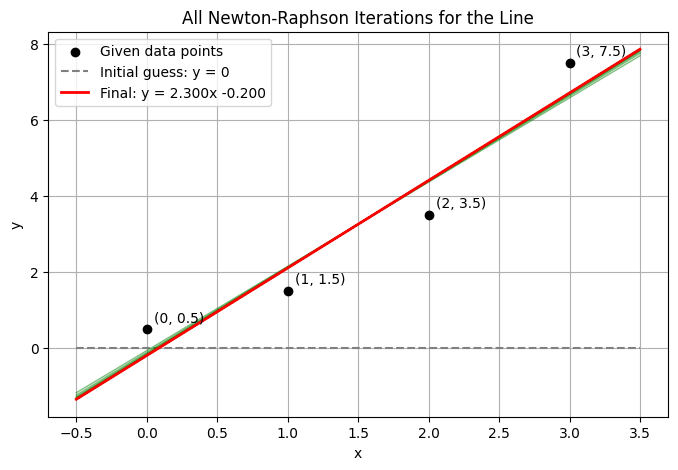

In [12]:
x_plot = np.linspace(
    np.min(x_data) - 0.5,
    np.max(x_data) + 0.5,
    200
)

line_history = line_newton_result["data"]

plt.figure(figsize=(8, 5))

# plot original data points
plt.scatter(
    x_data,
    y_data,
    color="black",
    label="Given data points",
    zorder=3
)

# label original data points
for x, y in points:
    plt.annotate(
        f"({x}, {y})",
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

# plot the initial guess
plt.plot(
    x_plot,
    np.zeros_like(x_plot),
    color="gray",
    linestyle="--",
    label="Initial guess: y = 0"
)

# plot every stored iteration
for _, row in line_history.iterrows():
    m_value = row["m"]
    b_value = row["b"]

    y_plot = m_value * x_plot + b_value

    plt.plot(
        x_plot,
        y_plot,
        color="green",
        alpha=0.5,
        linewidth=1
    )

# highlight the final line
final_line = line_history.iloc[-1]

final_m = final_line["m"]
final_b = final_line["b"]

final_y = final_m * x_plot + final_b

plt.plot(
    x_plot,
    final_y,
    color="red",
    linewidth=2,
    label=(
        f"Final: y = {final_m:.3f}x "
        f"{final_b:+.3f}"
    )
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("All Newton-Raphson Iterations for the Line")
plt.legend()
plt.grid(True)
plt.show()

### b) Parabola

The following plot shows the resulting parabola from each of the iterations of the Newton-Raphson method. The initial guess is the gray dotted curve, each iteration is shown in light green and the final fitted parabola is shown in red. The given data points are also displayed.

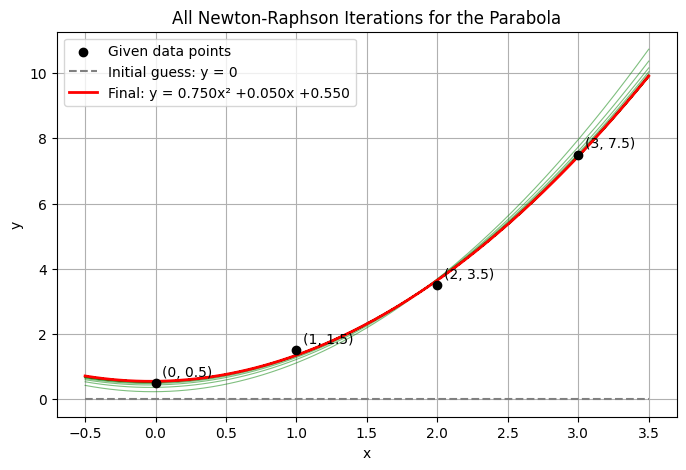

In [13]:
x_plot = np.linspace(
    np.min(x_data) - 0.5,
    np.max(x_data) + 0.5,
    200
)

parabola_history = parabola_newton_result["data"]

plt.figure(figsize=(8, 5))

# plot original data points
plt.scatter(
    x_data,
    y_data,
    color="black",
    label="Given data points",
    zorder=3
)

# label original data points
for x, y in points:
    plt.annotate(
        f"({x}, {y})",
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

# plot the initial guess
plt.plot(
    x_plot,
    np.zeros_like(x_plot),
    color="gray",
    linestyle="--",
    label="Initial guess: y = 0"
)

# plot every stored iteration
for _, row in parabola_history.iterrows():
    a_value = row["a"]
    b_value = row["b"]
    c_value = row["c"]

    y_plot = (
        a_value * x_plot**2
        + b_value * x_plot
        + c_value
    )

    plt.plot(
        x_plot,
        y_plot,
        color="green",
        alpha=0.5,
        linewidth=0.8
    )

# highlight the final parabola
final_parabola = parabola_history.iloc[-1]

final_a = final_parabola["a"]
final_b = final_parabola["b"]
final_c = final_parabola["c"]

final_y = (
    final_a * x_plot**2
    + final_b * x_plot
    + final_c
)

plt.plot(
    x_plot,
    final_y,
    color="red",
    linewidth=2,
    label=(
        f"Final: y = {final_a:.3f}x² "
        f"{final_b:+.3f}x "
        f"{final_c:+.3f}"
    )
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("All Newton-Raphson Iterations for the Parabola")
plt.legend()
plt.grid(True)
plt.show()